In [1]:
import scanpy as sc
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import calinski_harabasz_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Retrieve the Geneformer embeddings


In [2]:
adata = sc.read_h5ad("adata_embedded.h5ad")

In [3]:
X_Geneformer = adata.obsm["X_Geneformer"]
X_Geneformer_perturbed = adata.obsm["X_Geneformer_perturbed"]

# Sensitivity analysis

First, we can see how much the embeddings shift (before and after perturbation).


In [4]:
diff = X_Geneformer_perturbed - X_Geneformer

adata.obs["sensitivity"] = np.linalg.norm(diff, ord=2, axis=1) / np.linalg.norm(X_Geneformer, ord=2, axis=1)

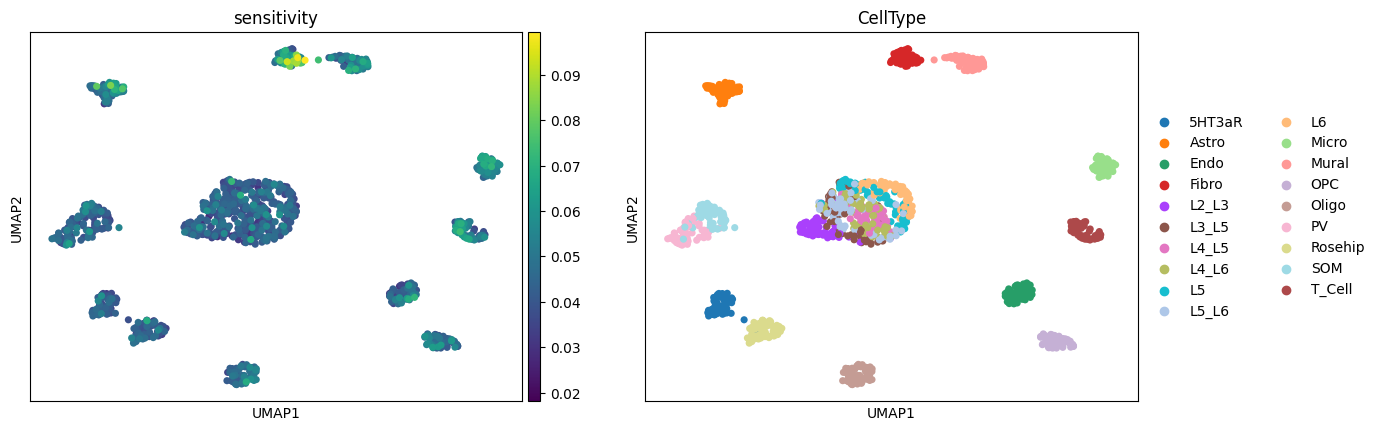

In [5]:
sc.pl.umap(adata, color=["sensitivity", "CellType"])

Here are the top 5 cell-types that shifted the most:


In [6]:
adata.obs.groupby("CellType", observed=True)["sensitivity"].mean().sort_values(ascending=False).head()

CellType
Fibro     0.061329
Micro     0.054127
T_Cell    0.051918
Astro     0.051027
Mural     0.050596
Name: sensitivity, dtype: float32

# Cosine similarity

Similary, we can also use the cosine similarity to quantify how much the embeddings changed.

The results are similar (but, of course, is the opposite direction).


In [7]:
adata.obs["cosine_similarity"] = np.sum(X_Geneformer * X_Geneformer_perturbed, axis=1) / (
    np.linalg.norm(X_Geneformer, axis=1) * np.linalg.norm(X_Geneformer_perturbed, axis=1)
)

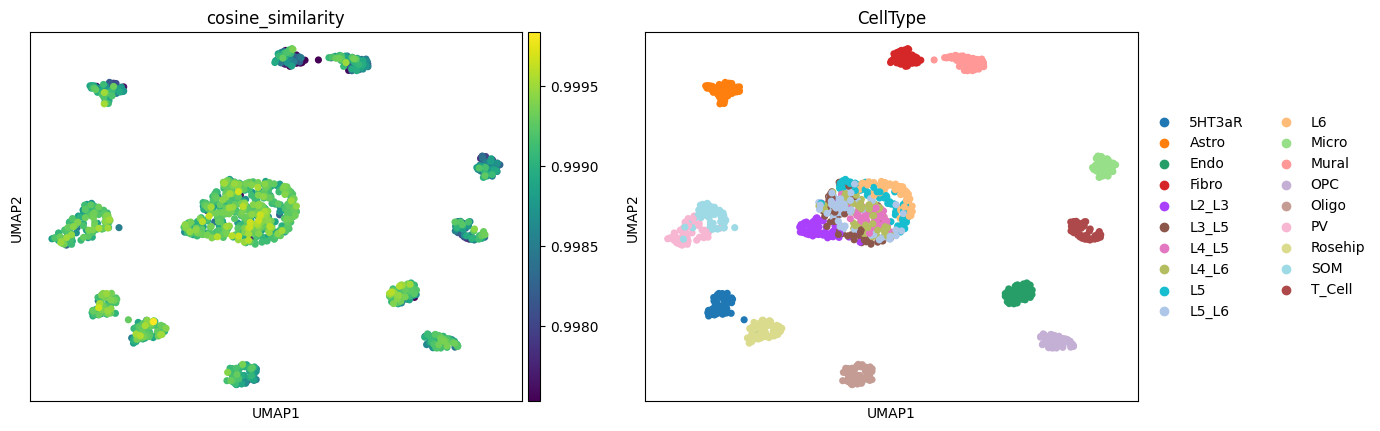

In [8]:
sc.pl.umap(adata, color=["cosine_similarity", "CellType"], vmin="p02")

# Healthy neighborhood ratio

We can also train a kNN classifier on all the unperturbed data, and transform the perturbed data to see how many PN neighbors in has compared to ALS neighbors.


In [ ]:
k = 10  # get the 10 knn for each cell

nn = NearestNeighbors(n_neighbors=k, algorithm="auto", metric="euclidean")
nn.fit(X_Geneformer)

distances, indices = nn.kneighbors(X_Geneformer_perturbed)

adata.obs["healthy_neighborhood_ratio"] = (adata.obs["Condition"].values == "PN")[indices].mean(axis=1)

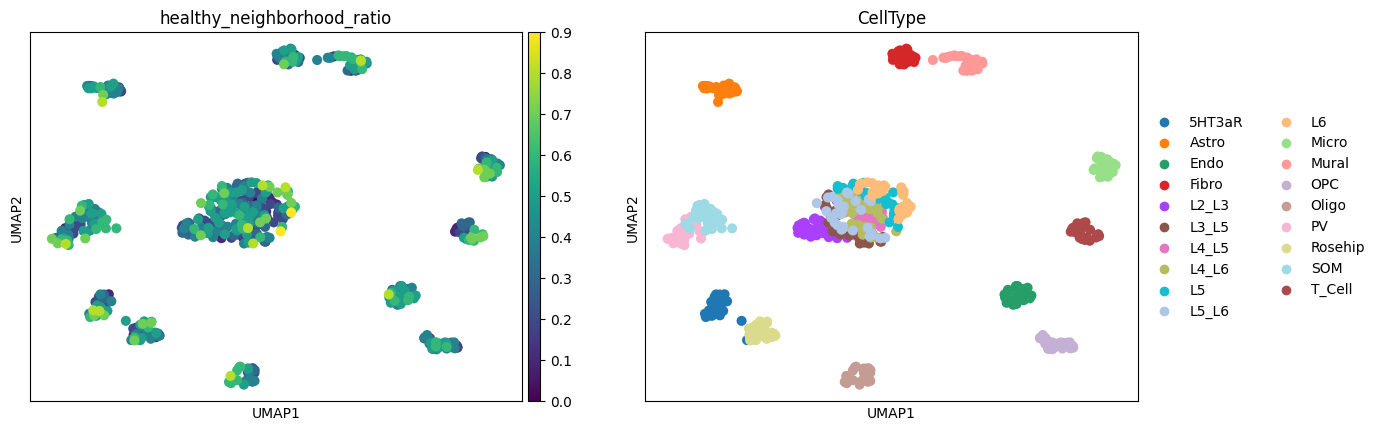

In [6]:
sc.pl.umap(adata[adata.obs["Condition"] == "ALS"], color=["healthy_neighborhood_ratio", "CellType"])

# Clustering mixing improvement

We can also compute for each cell-type how much the embeddings after perturbation shifted towards the "healthy" cluster, in terms of clustering.


In [ ]:
ALS = adata.obs["Condition"] == "ALS"
PN = adata.obs["Condition"] == "PN"


def cell_type_mixing_score(cell_type: str):
    is_cell_type = adata.obs["CellType"] == cell_type

    X1 = adata[is_cell_type & ALS].obsm["X_Geneformer"]
    labels1 = np.full(len(X1), "ALS")

    X2 = adata[is_cell_type & PN].obsm["X_Geneformer"]
    labels2 = np.full(len(X2), "PN")

    X3 = adata[is_cell_type & ALS].obsm["X_Geneformer_perturbed"]
    labels3 = np.full(len(X3), "ALS")

    original = calinski_harabasz_score(np.concat([X1, X2], axis=0), np.concat([labels1, labels2], axis=0))
    objective = calinski_harabasz_score(np.concat([X3, X2], axis=0), np.concat([labels3, labels2], axis=0))

    # we want the original clustering to be good compared to the new one (i.e. better mixing after perturbation)
    return original - objective

And plot the results:


<Axes: >

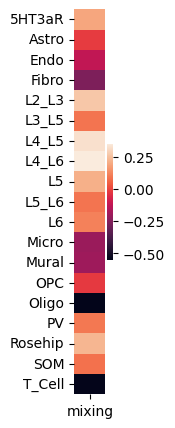

In [ ]:
cell_types = adata.obs["CellType"].unique()
scores = pd.DataFrame({"mixing": [cell_type_mixing_score(cell_type) for cell_type in cell_types]}, index=cell_types)

plt.figure(figsize=(0.5, 5))
sns.heatmap(scores)